In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.stats
import pandas as pd
import pyfish
import matplotlib.colors as colors
import matplotlib.cm as cm

In [139]:
font = {'family' : 'Helvetica Neue',
        'weight' : 'normal',
        'size'   : 20}

plt.rc('font', **font)

In [140]:
with open('mu_sweep_correlation_data_export.pkl','rb') as file:
    df = pd.read_pickle('mu_sweep_correlation_data_export.pkl')

In [141]:
df

,model,L,N,T,mu,trial,correlation_data
0,wrightfisher,10,1000,1000,0.003162,9,rare_cutoffs_log10 N_common_variants pea...
1,wrightfisher,10,1000,1000,0.001000,0,rare_cutoffs_log10 N_common_variants pea...
2,wrightfisher,10,1000,1000,0.000001,3,rare_cutoffs_log10 N_common_variants pea...
3,wrightfisher,10,1000,1000,0.001000,7,rare_cutoffs_log10 N_common_variants pea...
4,wrightfisher,10,1000,1000,0.000001,4,rare_cutoffs_log10 N_common_variants pea...
...,...,...,...,...,...,...,...
115,wrightfisher,10,1000,1000,0.000001,9,rare_cutoffs_log10 N_common_variants pea...
116,wrightfisher,10,1000,1000,0.000032,5,rare_cutoffs_log10 N_common_variants pea...
117,wrightfisher,10,1000,1000,0.003162,3,rare_cutoffs_log10 N_common_variants pea...
118,wrightfisher,10,1000,1000,0.000010,2,rare_cutoffs_log10 N_common_variants pea...


/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8629/2588790623.py:36: RuntimeWarning: Mean of empty slice
  pearson_means = np.nanmean(pearson_table, axis=1)[:cutoffs_to_keep]


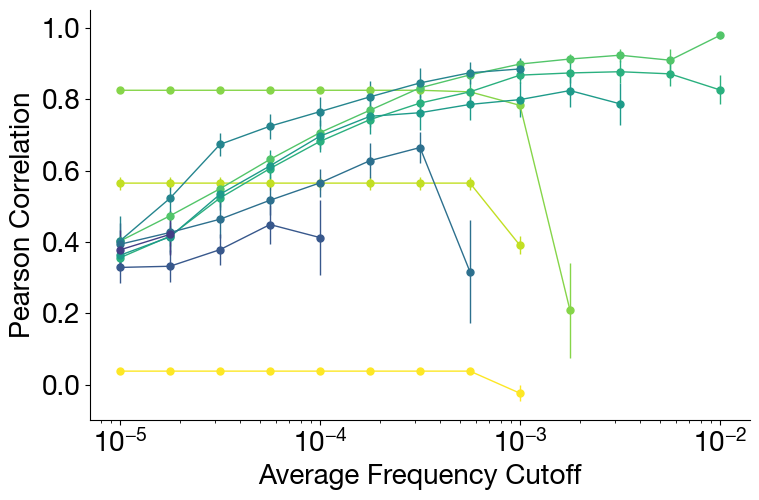

In [142]:
mu_list = np.logspace(-6,-0.5,12)
logmu_list = np.linspace(-6,-0.5,12)

fig, axs = plt.subplots(1,1,figsize=(8,5.4))
plt.tight_layout()

norm = colors.Normalize(vmin=min(logmu_list), vmax=max(logmu_list))
cmap = cm.viridis

for m in range(len(mu_list)-1,-1,-1):
    Npop = 1000
    Tsim = 1000
    cutoffs_to_keep = 14

    current_df = df[
        (df['model'] == 'wrightfisher') &
        (df['N'] == Npop) & 
        (df['T'] == Tsim) & 
        (df['mu'] == mu_list[m])
    ].reset_index(drop=True)

    # print(current_df)

    Ntrials = current_df.shape[0]
    Ndata = current_df['correlation_data'][0].shape[0]

    pearson_table = np.zeros((Ndata, Ntrials))
    N_common_variants_table = np.zeros((Ndata, Ntrials))
    rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

    for i in range(current_df.shape[0]):
        correlation_data = current_df['correlation_data'][i]
        pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
        N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

    pearson_means = np.nanmean(pearson_table, axis=1)[:cutoffs_to_keep]
    pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
    Npoints_means = np.nanmean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
    Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)


    x = 10**rare_cutoffs_log10[Npoints_means>10]
    y = pearson_means[Npoints_means>10]
    yerr = pearson_sterrs[Npoints_means>10]
    color = cmap(norm(logmu_list[m]))
    if len(x) == 0:
        axs.errorbar(x=x,y=y,yerr=yerr,marker='o',alpha=1,markersize=5,linestyle='-',linewidth=1,label=fr'$\mu = 10^{{{logmu_list[m]}}}$, no points with > 10 fitnesses', color=color)
    else:
        axs.errorbar(x=x,y=y,yerr=yerr,marker='o',alpha=1,markersize=5,linestyle='-',linewidth=1,label=fr'$\mu = 10^{{{logmu_list[m]}}}$', color=color)

axs.set_xlabel('Average Frequency Cutoff')
axs.set_ylabel('Pearson Correlation')
axs.set_xscale('log')
axs.spines[['right', 'top']].set_visible(False)
axs.set_ylim(-0.1,1.05)

# axs.legend(loc='lower left',fontsize=10)

plt.tight_layout()
plt.savefig('paper_plots/mu_rate_pearson_vs_freq.pdf')

/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8629/4266414491.py:36: RuntimeWarning: Mean of empty slice
  pearson_means = np.nanmean(pearson_table, axis=1)[:cutoffs_to_keep]


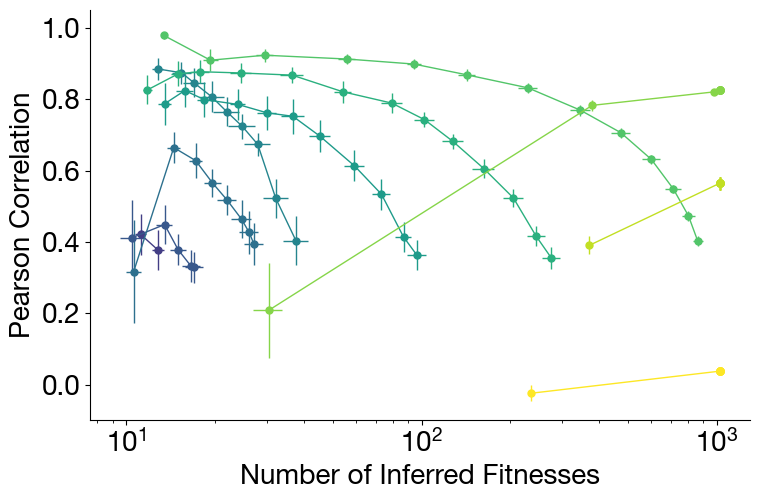

In [148]:
mu_list = np.logspace(-6,-0.5,12)
logmu_list = np.linspace(-6,-0.5,12)

fig, axs = plt.subplots(1,1,figsize=(8,5.4))
plt.tight_layout()

norm = colors.Normalize(vmin=min(logmu_list), vmax=max(logmu_list))
cmap = cm.viridis

for m in range(0,len(mu_list)):
    Npop = 1000
    Tsim = 1000
    cutoffs_to_keep = 14

    current_df = df[
        (df['model'] == 'wrightfisher') &
        (df['N'] == Npop) & 
        (df['T'] == Tsim) & 
        (df['mu'] == mu_list[m])
    ].reset_index(drop=True)

    # print(current_df)

    Ntrials = current_df.shape[0]
    Ndata = current_df['correlation_data'][0].shape[0]

    pearson_table = np.zeros((Ndata, Ntrials))
    N_common_variants_table = np.zeros((Ndata, Ntrials))
    rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

    for i in range(current_df.shape[0]):
        correlation_data = current_df['correlation_data'][i]
        pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
        N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

    pearson_means = np.nanmean(pearson_table, axis=1)[:cutoffs_to_keep]
    pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
    Npoints_means = np.nanmean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
    Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)


    x = Npoints_means[Npoints_means>10]
    xerr = Npoints_sterrs[Npoints_means>10]
    y = pearson_means[Npoints_means>10]
    yerr = pearson_sterrs[Npoints_means>10]
    color = cmap(norm(logmu_list[m]))
    axs.errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='o',alpha=1,markersize=5,linestyle='-',linewidth=1,label='$\mu$ = 1e' + str(logmu_list[m]), color=color)


axs.set_xlabel('Number of Inferred Fitnesses')
axs.set_ylabel('Pearson Correlation')
axs.set_xscale('log')
axs.spines[['right', 'top']].set_visible(False)
axs.set_ylim(-0.1,1.05)

# axs.legend(loc='lower left',fontsize=10)

plt.tight_layout()
plt.savefig('paper_plots/mu_rate_pearson_vs_num_inferred.pdf')

/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8629/2779316553.py:36: RuntimeWarning: Mean of empty slice
  pearson_means = np.nanmean(pearson_table, axis=1)[:cutoffs_to_keep]


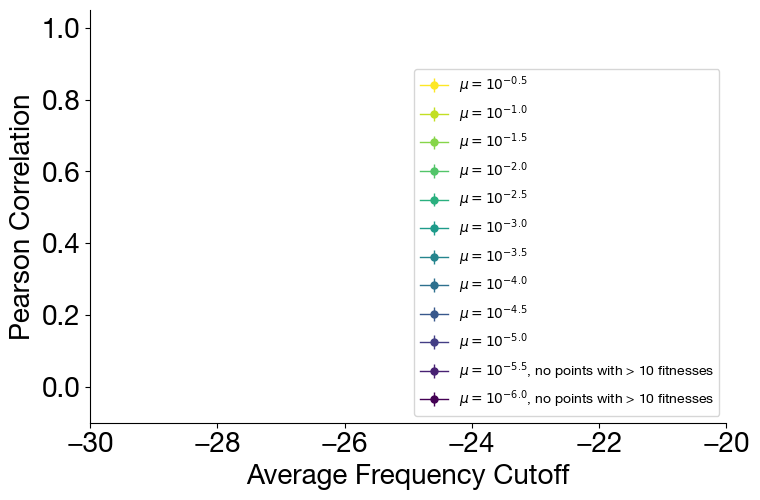

In [152]:
mu_list = np.logspace(-6,-0.5,12)
logmu_list = np.linspace(-6,-0.5,12)

fig, axs = plt.subplots(1,1,figsize=(8,5.4))
plt.tight_layout()

norm = colors.Normalize(vmin=min(logmu_list), vmax=max(logmu_list))
cmap = cm.viridis

for m in range(len(mu_list)-1,-1,-1):
    Npop = 1000
    Tsim = 1000
    cutoffs_to_keep = 14

    current_df = df[
        (df['model'] == 'wrightfisher') &
        (df['N'] == Npop) & 
        (df['T'] == Tsim) & 
        (df['mu'] == mu_list[m])
    ].reset_index(drop=True)

    # print(current_df)

    Ntrials = current_df.shape[0]
    Ndata = current_df['correlation_data'][0].shape[0]

    pearson_table = np.zeros((Ndata, Ntrials))
    N_common_variants_table = np.zeros((Ndata, Ntrials))
    rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

    for i in range(current_df.shape[0]):
        correlation_data = current_df['correlation_data'][i]
        pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
        N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

    pearson_means = np.nanmean(pearson_table, axis=1)[:cutoffs_to_keep]
    pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
    Npoints_means = np.nanmean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
    Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)


    x = 10**rare_cutoffs_log10[Npoints_means>10]
    y = pearson_means[Npoints_means>10]
    yerr = pearson_sterrs[Npoints_means>10]
    color = cmap(norm(logmu_list[m]))
    if len(x) == 0:
        axs.errorbar(x=x,y=y,yerr=yerr,marker='o',alpha=1,markersize=5,linestyle='-',linewidth=1,label=fr'$\mu = 10^{{{logmu_list[m]}}}$, no points with > 10 fitnesses', color=color)
    else:
        axs.errorbar(x=x,y=y,yerr=yerr,marker='o',alpha=1,markersize=5,linestyle='-',linewidth=1,label=fr'$\mu = 10^{{{logmu_list[m]}}}$', color=color)

axs.set_xlabel('Average Frequency Cutoff')
axs.set_ylabel('Pearson Correlation')
# axs.set_xscale('log')
axs.spines[['right', 'top']].set_visible(False)
axs.set_ylim(-0.1,1.05)
axs.set_xlim(-30,-20)

axs.legend(loc='lower right',fontsize=10)

plt.tight_layout()
plt.savefig('paper_plots/legend.pdf')